In [19]:
from SDP_interaction_inference import simulation
from SDP_interaction_inference import optimization
from SDP_interaction_inference.dataset import Dataset
from SDP_interaction_inference.constraints import Constraint
from SDP_interaction_inference import optimization_MOSEK
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tqdm

In [5]:
rng = np.random.default_rng(342)

In [6]:
def correlation_bootstrap_sample(sample, beta, confidence=None, resamples=None):

    # get sample size
    n = sample.shape[0]

    # get bootstrap size: default to sample size
    if resamples is None:
        resamples = n
    # confidence level: default to 95%
    if confidence is None:
        confidence = 0.95

    # initialize random generator
    rng = np.random.default_rng()

    # bootstrap to N x n x 2 array
    boot = rng.choice(sample, size=(resamples, n))

    # capture moments
    E_beta = np.mean(beta)
    E_beta2 = np.mean(beta**2)

    # compute correlations
    estimates = np.zeros(resamples)
    for i in range(resamples):

        b1 = boot[i, :, 0]
        b2 = boot[i, :, 1]

        # OB moments
        E_xy_OB = np.mean(b1 * b2)
        E_x_OB = np.mean(b1)
        E_y_OB = np.mean(b2)
        E_x2_OB = np.mean(b1**2)
        E_y2_OB = np.mean(b2**2)

        # OG moments
        E_xy_OG = E_xy_OB / E_beta2
        E_x_OG = E_x_OB / E_beta
        E_y_OG = E_y_OB / E_beta
        E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
        E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

        varx_OG = E_x2_OG - E_x_OG**2
        vary_OG = E_y2_OG - E_y_OG**2

        if varx_OG <= 0.0 or vary_OG <= 0.0:
            corr = np.nan
        else:
            corr = (E_xy_OG - E_x_OG*E_y_OG) / (np.sqrt(varx_OG) * np.sqrt(vary_OG))

        estimates[i] = corr

    # take quantiles
    alpha = 1 - confidence
    interval = np.quantile(estimates, [(alpha / 2), 1 - (alpha / 2)])

    # compute point estimate from original sample
    b1 = sample[:, 0]
    b2 = sample[:, 1]

    # OB moments
    E_xy_OB = np.mean(b1 * b2)
    E_x_OB = np.mean(b1)
    E_y_OB = np.mean(b2)
    E_x2_OB = np.mean(b1**2)
    E_y2_OB = np.mean(b2**2)

    # OG moments
    E_xy_OG = E_xy_OB / E_beta2
    E_x_OG = E_x_OB / E_beta
    E_y_OG = E_y_OB / E_beta
    E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
    E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

    varx_OG = E_x2_OG - E_x_OG**2
    vary_OG = E_y2_OG - E_y_OG**2

    if varx_OG <= 0.0 or vary_OG <= 0.0:
        corr = np.nan
    else:
        corr = (E_xy_OG - E_x_OG*E_y_OG) / (np.sqrt(varx_OG) * np.sqrt(vary_OG))

    # collect results
    result = np.array([
        corr,
        interval[0],
        interval[1]
    ])

    return result

In [7]:
def correlation_bootstrap_dataset(dataset, confidence=None, resamples=None):
    '''Bootstrap dataset correlations.'''

    # record results
    results = np.empty((dataset.gene_pairs, 3))
    
    # bootstrap
    for i in tqdm.tqdm(range(dataset.gene_pairs)):
        results[i, :] = correlation_bootstrap_sample(np.array([*dataset.count_dataset.iloc[i].values]), np.ones(dataset.cells), confidence, resamples)

    return results

In [8]:
def analytic_correlation_bootstrap_dataset(dataset, confidence=None, resamples=None):
    '''Bootstrap dataset correlations adjusted for capture efficiency.'''

    # record results
    results = np.empty((dataset.gene_pairs, 3))
    
    # bootstrap
    for i in tqdm.tqdm(range(dataset.gene_pairs)):
        results[i, :] = correlation_bootstrap_sample(np.array([*dataset.count_dataset.iloc[i].values]), dataset.beta, confidence, resamples)

    return results

## Minimal Test

In [101]:
# settings
k_reg = 2
k_tx = 1
mean_capture = 0.5
cells = 1000
d_boot = 6
confidence = 0.95

# simulate sample
dataset_original = simulation.simulate_dataset_range_BD([k_reg], rate=k_tx, tqdm_disable=False)

# downsample
b = (1 / mean_capture) - 1
if b == 0   :
    beta = np.ones(cells)
else:
    beta = rng.beta(1, b, size=cells)
dataset = dataset_original.downsample(beta)

# bootstrap
dataset.confidence = confidence
dataset.bootstrap(d_boot, tqdm_disable=False)

100%|██████████| 1/1 [00:00<00:00,  4.32it/s]


In [102]:
# bootstrap correlation statistic of samples
true_correlation_OG = correlation_bootstrap_dataset(dataset_original, confidence=confidence)
true_correlation_OB = correlation_bootstrap_dataset(dataset, confidence=confidence)

# compute analytic correlation estimate: adjusts correlation of observed sample for capture efficiency
analytic_correlation = analytic_correlation_bootstrap_dataset(dataset, confidence=confidence)

100%|██████████| 1/1 [00:00<00:00, 14.24it/s]


In [103]:
# optimization settings
d = 3
N = 1000

# cutting plane
constraints = Constraint(
    moment_bounds=True,
    moment_matrices=True,
    factorization=False
)
opt_cut = optimization.ModelFreeOptimization(dataset, d, constraints=constraints, printing=False, silent=True)
opt_cut.analyse_dataset()

# MOSEK Hit and Run
opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, N=N)
opt_har.analyse_dataset()

# MOSEK random linear objectives
opt_rnd = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, method_opt="random", N=N)
opt_rnd.analyse_dataset()

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.77s/it]


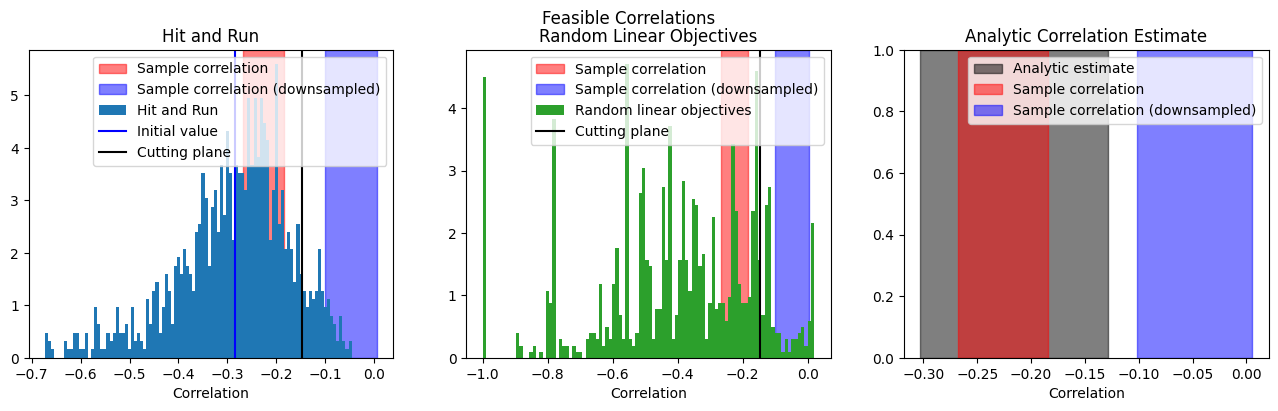

In [104]:
fig, axs = plt.subplots(1, 3, squeeze=False, figsize=(16, 4))
# Hit and Run
axs[0, 0].axvspan(*true_correlation_OG[0, 1:], alpha=0.5, color="red", label="Sample correlation")
axs[0, 0].axvspan(*true_correlation_OB[0, 1:], alpha=0.5, color="blue", label="Sample correlation (downsampled)")
axs[0, 0].hist(opt_har.result_dict_HAR[0]['feasible_correlations'], density=True, bins=100, color="C0", label="Hit and Run",);
axs[0, 0].axvline(opt_har.result_dict_optimization[0]['feasible_correlations'], color="blue", label="Initial value")
axs[0, 0].axvline(opt_cut.result_dict[0]['correlation'], color="black", label="Cutting plane")
axs[0, 0].set_xlabel("Correlation")
axs[0, 0].set_title("Hit and Run")
axs[0, 0].legend()
# Random Linear Objectives
axs[0, 1].axvspan(*true_correlation_OG[0, 1:], alpha=0.5, color="red", label="Sample correlation")
axs[0, 1].axvspan(*true_correlation_OB[0, 1:], alpha=0.5, color="blue", label="Sample correlation (downsampled)")
axs[0, 1].hist(opt_rnd.result_dict_optimization[0]['feasible_correlations'], density=True, bins=100, color="C2", label="Random linear objectives");
axs[0, 1].axvline(opt_cut.result_dict[0]['correlation'], color="black", label="Cutting plane")
axs[0, 1].set_xlabel("Correlation")
axs[0, 1].set_title("Random Linear Objectives")
axs[0, 1].legend()
# Analytic
axs[0, 2].axvspan(*analytic_correlation[0, 1:], alpha=0.5, color="black", label="Analytic estimate")
axs[0, 2].axvspan(*true_correlation_OG[0, 1:], alpha=0.5, color="red", label="Sample correlation")
axs[0, 2].axvspan(*true_correlation_OB[0, 1:], alpha=0.5, color="blue", label="Sample correlation (downsampled)")
axs[0, 2].set_xlabel("Correlation")
axs[0, 2].set_title("Analytic Correlation Estimate")
axs[0, 2].legend()
fig.suptitle("Feasible Correlations")
plt.show()

100%|██████████| 1/1 [00:01<00:00,  1.66s/it]


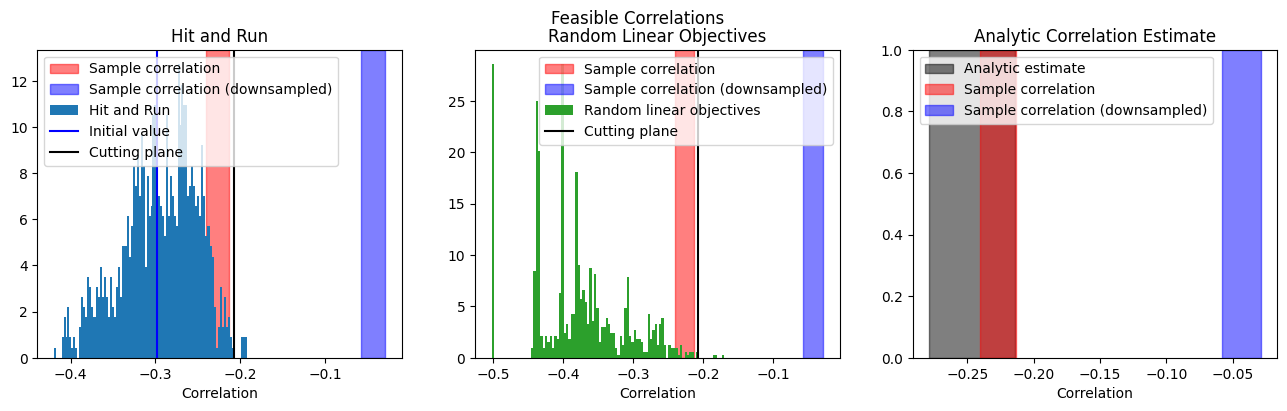

In [115]:
# settings
k_reg = 5
k_tx = 1
mean_capture = 0.25
cells = 1000
d_boot = 6
confidence = 0.5

# optimization settings
d = 3
N = 1000

# simulate sample
dataset_original = simulation.simulate_dataset_range_BD([k_reg], rate=k_tx, tqdm_disable=False)

# downsample
b = (1 / mean_capture) - 1
if b == 0   :
    beta = np.ones(cells)
else:
    beta = rng.beta(1, b, size=cells)
dataset = dataset_original.downsample(beta)

# bootstrap
dataset.confidence = confidence
dataset.bootstrap(d_boot, tqdm_disable=False)

# bootstrap correlation statistic of samples
true_correlation_OG = correlation_bootstrap_dataset(dataset_original, confidence=confidence)
true_correlation_OB = correlation_bootstrap_dataset(dataset, confidence=confidence)

# compute analytic correlation estimate: adjusts correlation of observed sample for capture efficiency
analytic_correlation = analytic_correlation_bootstrap_dataset(dataset, confidence=confidence)

# cutting plane
constraints = Constraint(
    moment_bounds=True,
    moment_matrices=True,
    factorization=False
)
opt_cut = optimization.ModelFreeOptimization(dataset, d, constraints=constraints, printing=False, silent=True)
opt_cut.analyse_dataset()

# MOSEK Hit and Run
opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, N=N)
opt_har.analyse_dataset()

# MOSEK random linear objectives
opt_rnd = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, method_opt="random", N=N)
opt_rnd.analyse_dataset()

fig, axs = plt.subplots(1, 3, squeeze=False, figsize=(16, 4))
# Hit and Run
axs[0, 0].axvspan(*true_correlation_OG[0, 1:], alpha=0.5, color="red", label="Sample correlation")
axs[0, 0].axvspan(*true_correlation_OB[0, 1:], alpha=0.5, color="blue", label="Sample correlation (downsampled)")
axs[0, 0].hist(opt_har.result_dict_HAR[0]['feasible_correlations'], density=True, bins=100, color="C0", label="Hit and Run",);
axs[0, 0].axvline(opt_har.result_dict_optimization[0]['feasible_correlations'], color="blue", label="Initial value")
axs[0, 0].axvline(opt_cut.result_dict[0]['correlation'], color="black", label="Cutting plane")
axs[0, 0].set_xlabel("Correlation")
axs[0, 0].set_title("Hit and Run")
axs[0, 0].legend()
# Random Linear Objectives
axs[0, 1].axvspan(*true_correlation_OG[0, 1:], alpha=0.5, color="red", label="Sample correlation")
axs[0, 1].axvspan(*true_correlation_OB[0, 1:], alpha=0.5, color="blue", label="Sample correlation (downsampled)")
axs[0, 1].hist(opt_rnd.result_dict_optimization[0]['feasible_correlations'], density=True, bins=100, color="C2", label="Random linear objectives");
axs[0, 1].axvline(opt_cut.result_dict[0]['correlation'], color="black", label="Cutting plane")
axs[0, 1].set_xlabel("Correlation")
axs[0, 1].set_title("Random Linear Objectives")
axs[0, 1].legend()
# Analytic
axs[0, 2].axvspan(*analytic_correlation[0, 1:], alpha=0.5, color="black", label="Analytic estimate")
axs[0, 2].axvspan(*true_correlation_OG[0, 1:], alpha=0.5, color="red", label="Sample correlation")
axs[0, 2].axvspan(*true_correlation_OB[0, 1:], alpha=0.5, color="blue", label="Sample correlation (downsampled)")
axs[0, 2].set_xlabel("Correlation")
axs[0, 2].set_title("Analytic Correlation Estimate")
axs[0, 2].legend()
fig.suptitle("Feasible Correlations")
plt.show()

## Performance Testing: Simulated Data

- setup parameter sampling dataset constructor
- plot scatter of original point correlations vs method estimated intervals (H&R, Random, Analytic)

Also interested if any meaning of distribution of correlations (for hit and run)

In [20]:
def simulate_dataset(gene_pairs, cells, tqdm_diable=False):

    # construct paired count dataframe
    counts_df = pd.DataFrame(
        index = [f"Gene-pair-{i}" for i in range(gene_pairs)],
        columns = [f"Cell-{j}" for j in range(cells)]
    )

    # fill with pairs
    for i in tqdm.tqdm(range(gene_pairs), disable=tqdm_diable):

        # sample parameters
        k_on = 1
        k_off = rng.integers(0, 2)
        k_tx = rng.integers(1, 3)
        k_deg = 1
        k_reg = rng.integers(0, 3)

        # simulate data
        params = {
            'k_on_1': k_on,
            'k_on_2': k_on,
            'k_off_1': k_off,
            'k_off_2': k_off,
            'k_tx_1': k_tx,
            'k_tx_2': k_tx,
            'k_deg_1': k_deg,
            'k_deg_2': k_deg,
            'k_reg': k_reg
        }
        sample = simulation.gillespie_telegraph(params, cells)

        # store
        counts_df.iloc[i] = sample

    # construct dataset object
    data = Dataset()
    data.count_dataset = counts_df
    data.cells = cells
    data.gene_pairs = gene_pairs

    # set capture
    data.beta = np.ones(cells)

    return data

In [120]:
def downsample_dataset(dataset_original, mean_capture):

    b = (1 / mean_capture) - 1
    if b == 0   :
        beta = np.ones(dataset_original.cells)
    else:
        beta = rng.beta(1, b, size=dataset_original.cells)
    dataset = dataset_original.downsample(beta)

    return dataset

In [122]:
def plot_original_observed_correlations(true_correlation_OB, true_correlation_OG):

    plt.scatter(true_correlation_OB[:, 0], true_correlation_OG[:, 0], color="blue", label="Bootstrap CI")
    for i in range(dataset_original.gene_pairs):
        plt.plot([true_correlation_OB[i, 0]] * 2, true_correlation_OG[i, 1:], color="blue")
        plt.plot(true_correlation_OB[i, 1:], [true_correlation_OG[i, 0]] * 2, color="blue")
    plt.axline([0, 0], [0.01, 0.01], color="red", label="Equality")
    plt.xlabel("Observed Correlation")
    plt.ylabel("Original Correlation")
    plt.title("Original vs Observed Correlation: Effect of Capture Efficiency")
    plt.legend()
    plt.show()

In [123]:
def plot_recovered_correlations(true_correlation_OG, opt_cut, opt_har, opt_rnd, analytic_correlation):

    # extract results
    G = opt_cut.dataset.gene_pairs

    # cutting plane
    opt_cut_corr = [res['correlation'] for res in opt_cut.result_dict.values()]

    # Hit and Run
    opt_har_corr = np.zeros((G, 3))
    for i in range(G):
        opt_har_corr[i, 0] = opt_har.result_dict_optimization[i]['feasible_correlations'][0]
        corrs = opt_har.result_dict_HAR[i]['feasible_correlations']
        opt_har_corr[i, 1] = np.min(corrs)
        opt_har_corr[i, 2] = np.max(corrs)

    # Random objectives
    opt_rnd_corr = np.zeros((G, 2))
    for i in range(G):
        corrs = opt_rnd.result_dict_optimization[i]['feasible_correlations']
        opt_rnd_corr[i, 0] = np.min(corrs)
        opt_rnd_corr[i, 1] = np.max(corrs)

    # plot
    fig, axs = plt.subplots(2, 2, squeeze=False, figsize=(8, 8))
    m = true_correlation_OG[:, 0].mean()

    # cutting plane & MOSEK single feasible points
    axs[0, 0].scatter(true_correlation_OG[:, 0], opt_cut_corr, color="black", label="Cutting plane")
    axs[0, 0].scatter(true_correlation_OG[:, 0], opt_har_corr[:, 0], color="blue", label="MOSEK")
    axs[0, 0].axline([m, m], [m+0.01, m+0.01], color="red")
    axs[0, 0].set_title("Single feasible point")
    axs[0, 0].legend()

    # Hit and Run
    for i in range(G):
        label = "Feasible range" if i == 0 else None
        axs[0, 1].plot([true_correlation_OG[i, 0]] * 2, opt_har_corr[i, 1:], color="blue", label=label)
    axs[0, 1].axline([m, m], [m+0.01, m+0.01], color="red")
    axs[0, 1].set_title("Hit and Run")
    axs[0, 1].legend()

    # Radom objectives
    for i in range(G):
        label = "Feasible range" if i == 0 else None
        axs[1, 0].plot([true_correlation_OG[i, 0]] * 2, opt_rnd_corr[i, :], color="green", label=label)
    axs[1, 0].axline([m, m], [m+0.01, m+0.01], color="red")
    axs[1, 0].set_title("Random linear objectives")
    axs[1, 0].legend()

    # Analytic
    axs[1, 1].scatter(true_correlation_OG[:, 0], analytic_correlation[:, 0], color="purple", label="Point estimate")
    for i in range(G):
        label = "Bootstrap CI" if i == 0 else None
        axs[1, 1].plot([true_correlation_OG[i, 0]] * 2, analytic_correlation[i, 1:], color="purple", label=label)
    axs[1, 1].axline([m, m], [m+0.01, m+0.01], color="red")
    axs[1, 1].set_title("Analytic Estimate")
    axs[1, 1].legend()

    fig.supxlabel("Original correlation")
    fig.supylabel("Recovered Original Correlation")
    plt.show()

In [121]:
# data settings
gene_pairs = 10
cells = 1000

# simulate data
dataset_original = simulate_dataset(gene_pairs, cells)

100%|██████████| 10/10 [00:12<00:00,  1.23s/it]


In [124]:
# capture settings
mean_capture = 0.25

# downsample
dataset = downsample_dataset(dataset_original, mean_capture)

In [125]:
# bootstrap settings
confidence = 0.95
d_boot = 4

# bootstrap moments
dataset.confidence = confidence
dataset.bootstrap(d_boot, tqdm_disable=False)

# bootstrap correlation statistic of samples
true_correlation_OG = correlation_bootstrap_dataset(dataset_original, confidence=confidence)
true_correlation_OB = correlation_bootstrap_dataset(dataset, confidence=confidence)

100%|██████████| 10/10 [00:00<00:00, 19.37it/s]


In [126]:
# analysis settings
d = 3
N = 1000

# cutting plane
constraints = Constraint(
    moment_bounds=True,
    moment_matrices=True,
    factorization=False
)
opt_cut = optimization.ModelFreeOptimization(dataset, d, constraints=constraints, printing=False, silent=True)
opt_cut.analyse_dataset()

# MOSEK Hit and Run
opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, N=N)
opt_har.analyse_dataset()

# MOSEK random linear objectives
opt_rnd = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, method_opt="random", N=N)
opt_rnd.analyse_dataset()

# compute analytic correlation estimate: adjusts correlation of observed sample for capture efficiency
analytic_correlation = analytic_correlation_bootstrap_dataset(dataset, confidence=confidence)

100%|██████████| 10/10 [00:00<00:00, 17.32it/s]


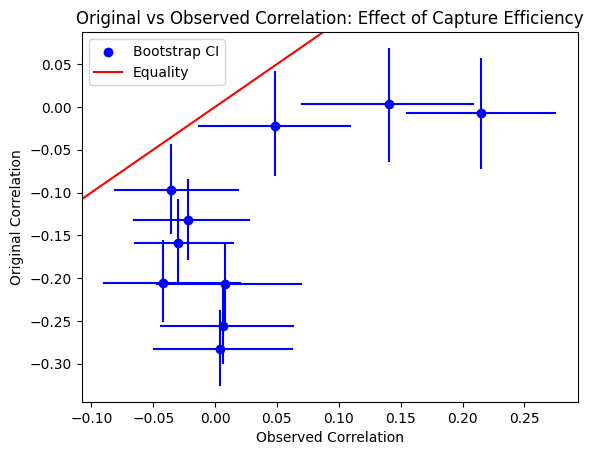

In [127]:
plot_original_observed_correlations(true_correlation_OB, true_correlation_OG)

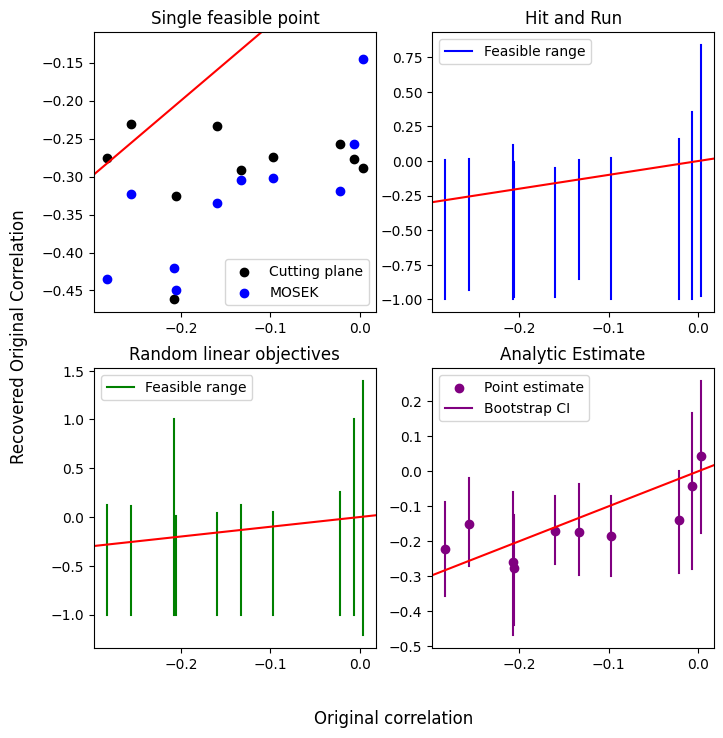

In [128]:
plot_recovered_correlations(true_correlation_OG, opt_cut, opt_har, opt_rnd, analytic_correlation)

### Lower confidence

In [129]:
# bootstrap settings
confidence = 0.5
d_boot = 4

# bootstrap moments
dataset.confidence = confidence
dataset.bootstrap(d_boot, tqdm_disable=False)

# bootstrap correlation statistic of samples
true_correlation_OG = correlation_bootstrap_dataset(dataset_original, confidence=confidence)
true_correlation_OB = correlation_bootstrap_dataset(dataset, confidence=confidence)

100%|██████████| 10/10 [00:00<00:00, 16.23it/s]


In [130]:
# analysis settings
d = 3
N = 1000

# cutting plane
constraints = Constraint(
    moment_bounds=True,
    moment_matrices=True,
    factorization=False
)
opt_cut = optimization.ModelFreeOptimization(dataset, d, constraints=constraints, printing=False, silent=True)
opt_cut.analyse_dataset()

# MOSEK Hit and Run
opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, N=N)
opt_har.analyse_dataset()

# MOSEK random linear objectives
opt_rnd = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, method_opt="random", N=N)
opt_rnd.analyse_dataset()

# compute analytic correlation estimate: adjusts correlation of observed sample for capture efficiency
analytic_correlation = analytic_correlation_bootstrap_dataset(dataset, confidence=confidence)

100%|██████████| 10/10 [00:00<00:00, 18.18it/s]


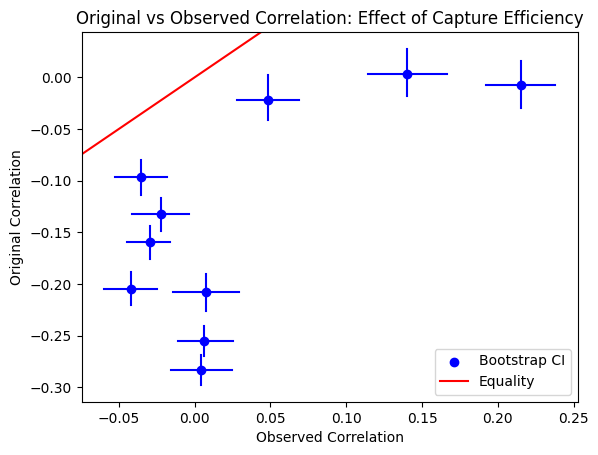

In [131]:
plot_original_observed_correlations(true_correlation_OB, true_correlation_OG)

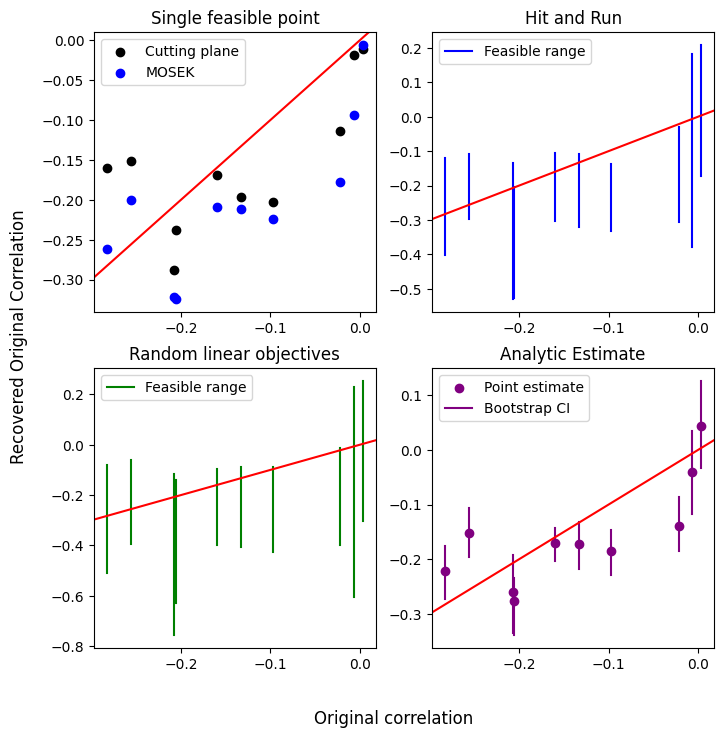

In [132]:
plot_recovered_correlations(true_correlation_OG, opt_cut, opt_har, opt_rnd, analytic_correlation)

### High capture

In [133]:
# capture settings
mean_capture = 0.75

# downsample
dataset = downsample_dataset(dataset_original, mean_capture)

In [134]:
# bootstrap settings
confidence = 0.95
d_boot = 4

# bootstrap moments
dataset.confidence = confidence
dataset.bootstrap(d_boot, tqdm_disable=False)

# bootstrap correlation statistic of samples
true_correlation_OG = correlation_bootstrap_dataset(dataset_original, confidence=confidence)
true_correlation_OB = correlation_bootstrap_dataset(dataset, confidence=confidence)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 17.69it/s]


In [135]:
# analysis settings
d = 3
N = 1000

# cutting plane
constraints = Constraint(
    moment_bounds=True,
    moment_matrices=True,
    factorization=False
)
opt_cut = optimization.ModelFreeOptimization(dataset, d, constraints=constraints, printing=False, silent=True)
opt_cut.analyse_dataset()

# MOSEK Hit and Run
opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, N=N)
opt_har.analyse_dataset()

# MOSEK random linear objectives
opt_rnd = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, method_opt="random", N=N)
opt_rnd.analyse_dataset()

# compute analytic correlation estimate: adjusts correlation of observed sample for capture efficiency
analytic_correlation = analytic_correlation_bootstrap_dataset(dataset, confidence=confidence)

100%|██████████| 10/10 [00:00<00:00, 16.02it/s]


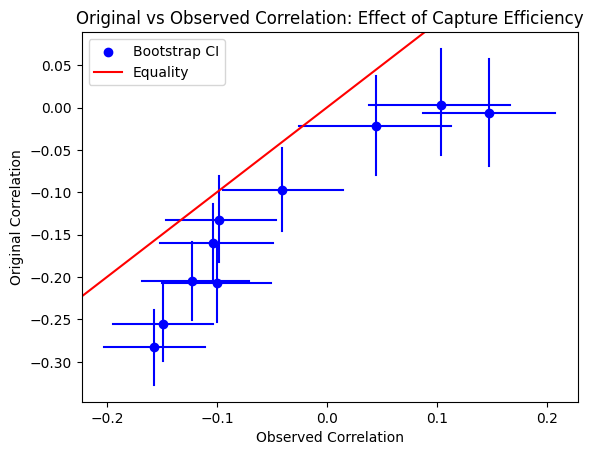

In [136]:
plot_original_observed_correlations(true_correlation_OB, true_correlation_OG)

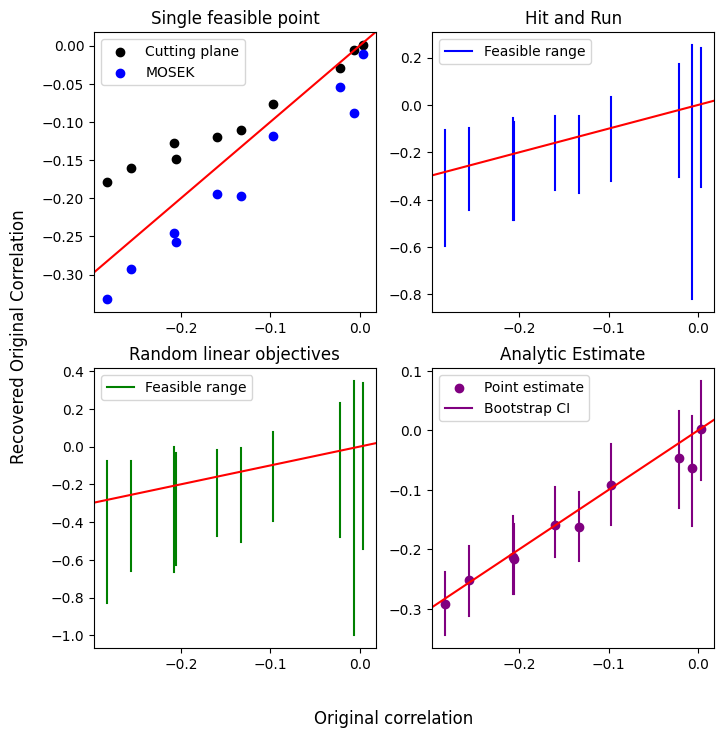

In [137]:
plot_recovered_correlations(true_correlation_OG, opt_cut, opt_har, opt_rnd, analytic_correlation)

### Large test

In [138]:
# data settings
gene_pairs = 100
cells = 1000

# simulate data
dataset_original = simulate_dataset(gene_pairs, cells)

100%|██████████| 100/100 [02:32<00:00,  1.53s/it]


In [139]:
# capture settings
mean_capture = 0.5

# downsample
dataset = downsample_dataset(dataset_original, mean_capture)

In [140]:
# bootstrap settings
confidence = 0.95
d_boot = 4

# bootstrap moments
dataset.confidence = confidence
dataset.bootstrap(d_boot, tqdm_disable=False)

# bootstrap correlation statistic of samples
true_correlation_OG = correlation_bootstrap_dataset(dataset_original, confidence=confidence)
true_correlation_OB = correlation_bootstrap_dataset(dataset, confidence=confidence)

100%|██████████| 100/100 [00:07<00:00, 13.29it/s]


In [141]:
# analysis settings
d = 3
N = 1000

# cutting plane
constraints = Constraint(
    moment_bounds=True,
    moment_matrices=True,
    factorization=False
)
opt_cut = optimization.ModelFreeOptimization(dataset, d, constraints=constraints, printing=False, silent=True)
opt_cut.analyse_dataset()

# MOSEK Hit and Run
opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, N=N)
opt_har.analyse_dataset()

# MOSEK random linear objectives
opt_rnd = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, method_opt="random", N=N)
opt_rnd.analyse_dataset()

# compute analytic correlation estimate: adjusts correlation of observed sample for capture efficiency
analytic_correlation = analytic_correlation_bootstrap_dataset(dataset, confidence=confidence)

100%|██████████| 100/100 [00:06<00:00, 14.34it/s]


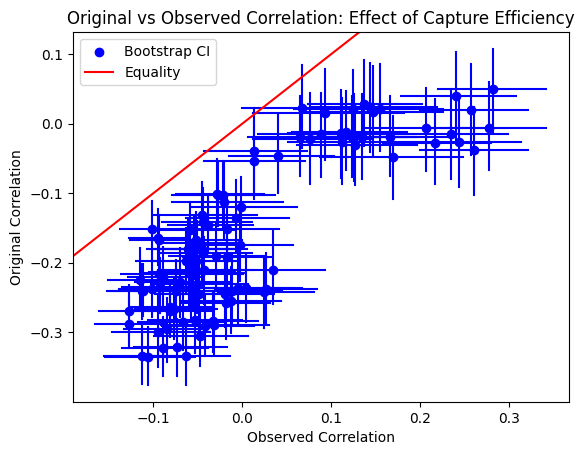

In [142]:
plot_original_observed_correlations(true_correlation_OB, true_correlation_OG)

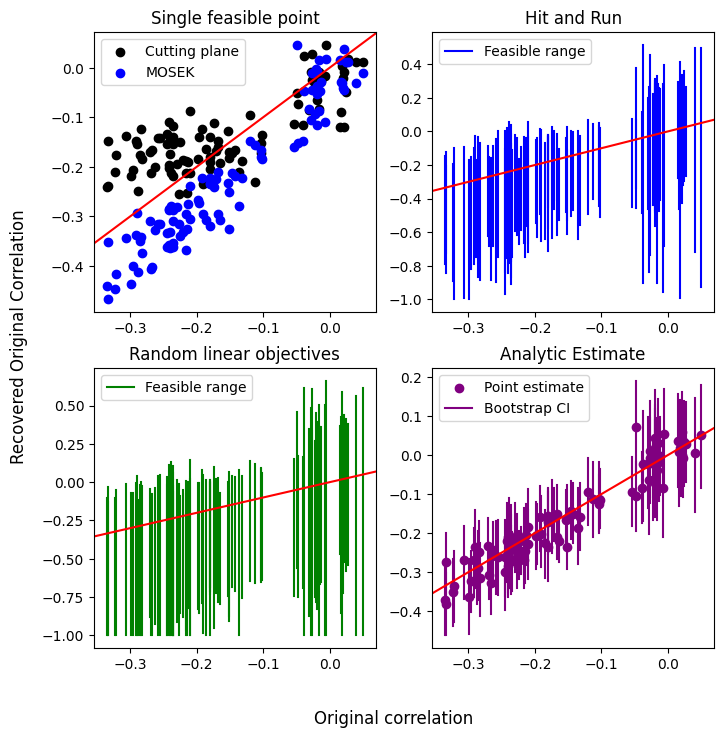

In [143]:
plot_recovered_correlations(true_correlation_OG, opt_cut, opt_har, opt_rnd, analytic_correlation)

#### Lower confidence

In [144]:
# bootstrap settings
confidence = 0.5
d_boot = 4

# bootstrap moments
dataset.confidence = confidence
dataset.bootstrap(d_boot, tqdm_disable=False)

# bootstrap correlation statistic of samples
true_correlation_OG = correlation_bootstrap_dataset(dataset_original, confidence=confidence)
true_correlation_OB = correlation_bootstrap_dataset(dataset, confidence=confidence)

100%|██████████| 100/100 [00:05<00:00, 17.65it/s]


In [145]:
# analysis settings
d = 3
N = 1000

# cutting plane
constraints = Constraint(
    moment_bounds=True,
    moment_matrices=True,
    factorization=False
)
opt_cut = optimization.ModelFreeOptimization(dataset, d, constraints=constraints, printing=False, silent=True)
opt_cut.analyse_dataset()

# MOSEK Hit and Run
opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, N=N)
opt_har.analyse_dataset()

# MOSEK random linear objectives
opt_rnd = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, method_opt="random", N=N)
opt_rnd.analyse_dataset()

# compute analytic correlation estimate: adjusts correlation of observed sample for capture efficiency
analytic_correlation = analytic_correlation_bootstrap_dataset(dataset, confidence=confidence)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:05<00:00, 16.95it/s]


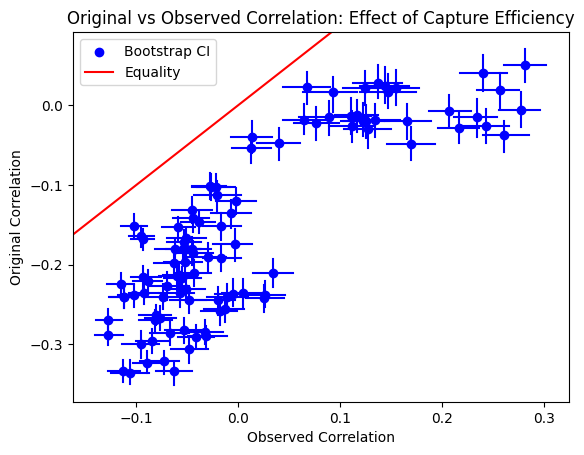

In [146]:
plot_original_observed_correlations(true_correlation_OB, true_correlation_OG)

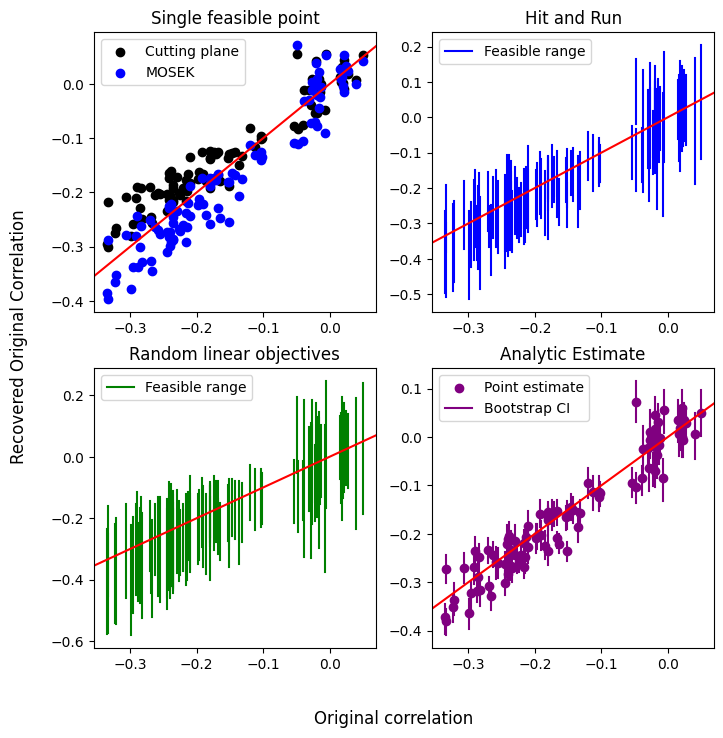

In [147]:
plot_recovered_correlations(true_correlation_OG, opt_cut, opt_har, opt_rnd, analytic_correlation)

In [ ]:
# simulate dataset
# sample capture and downsample
# bootstrap true correlations: original and observed
# display observed vs original correlations to see capture effects
# run methods: cut, MOSEK + H&R, random objectives, analytic
# display: scatter plot of true vs recovered original correlations, intervals for both?
# want to show distributions somehow

## Real Data Test

## Matrix Speedup test

In [4]:
# settings
k_reg = 2
k_tx = 1
mean_capture = 0.5
cells = 1000
d_boot = 6

# simulate sample
dataset = simulation.simulate_dataset_range_BD([k_reg], rate=k_tx, tqdm_disable=False)

# downsample
b = (1 / mean_capture) - 1
if b == 0   :
    beta = np.ones(cells)
else:
    beta = rng.beta(1, b, size=cells)
dataset = dataset.downsample(beta)

# bootstrap
dataset.bootstrap(d_boot, tqdm_disable=False)

100%|██████████| 1/1 [00:00<00:00,  4.33it/s]


In [8]:
# Hit and Run
opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d=3, N=10000)
opt_har.analyse_dataset()

100%|██████████| 1/1 [00:06<00:00,  6.57s/it]


In [ ]:
# Hit and Run: Matrix computation
opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d=3, N=10000)
opt_har.analyse_dataset(matrix=True)

100%|██████████| 1/1 [00:06<00:00,  6.36s/it]
